# Greenhouse Energy Hub MPC — Results Analysis

Rolling-horizon economic MPC vs. a **fair rule-based baseline** (a frugal thermostat that holds the lower comfort bound, so any saving reflects dispatch skill rather than simply running colder) for a multi-carrier greenhouse energy hub. Imported energy pays wholesale + a transport/levy surcharge; exports earn wholesale.

Figures are saved to `results/figures/` and used in the README. The committed canonical results are the **winter** window; regenerate any scenario with:
```bash
python3 control/rolling_horizon.py --days 14 --start-month 1   # winter (headline)
python3 control/rolling_horizon.py --days 14 --start-month 6   # summer
python3 experiments/ablations.py  --days 14 --start-month 1    # ablation study
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent
RESULTS = ROOT / 'results'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 130,
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})

b = pd.read_csv(RESULTS / 'baseline_results.csv', index_col='timestamp', parse_dates=True)
m = pd.read_csv(RESULTS / 'mpc_results.csv', index_col='timestamp', parse_dates=True)
print(f'Loaded {len(b)} rows (incl. terminal state): {b.index[0]} -> {b.index[-1]}')

Loaded 337 rows (incl. terminal state): 2023-01-01 00:00:00+00:00 -> 2023-01-15 00:00:00+00:00


## 1. Cost summary

Raw grid cost and **inventory-adjusted** cost (net stored energy marked to market at the mean price) come from the shared `accounting` module — the same calculation used by the CLI and the tests, so reported numbers cannot drift.

In [2]:
from greenhouse_energy_hub.evaluation import (
    _legacy_grid_inventory_adjusted_cost as inventory_adjusted_cost,
    saving_pct,
    stored_equiv_kwh,
)
from greenhouse_energy_hub.hub import initial_state

x0 = initial_state()
init_eq = stored_equiv_kwh(x0['SOC_bat'], x0['SOC_h2'], x0['SOC_tes'])
settle = m['price_EUR_kWh'].mean()

rows = []
for name, d in [('baseline', b), ('MPC', m)]:
    rows.append(dict(controller=name,
                     grid_cost_EUR=round(d['grid_cost_EUR'].sum(), 1),
                     inv_adjusted_EUR=round(inventory_adjusted_cost(d, init_eq, settle), 1),
                     Tband_viol_Ch=round(d['T_violation_C'].sum(), 1)))
summary = pd.DataFrame(rows).set_index('controller')
print(summary)
raw = saving_pct(summary.loc['baseline','grid_cost_EUR'], summary.loc['MPC','grid_cost_EUR'])
adj = saving_pct(summary.loc['baseline','inv_adjusted_EUR'], summary.loc['MPC','inv_adjusted_EUR'])
print(f'\nMPC saving: {raw:+.1f}% (raw grid cost)   {adj:+.1f}% (inventory-adjusted)')
print(f'Max electricity-balance residual: '
      f'{max(b.elec_residual_kW.abs().max(), m.elec_residual_kW.abs().max()):.2e} kW')

            grid_cost_EUR  inv_adjusted_EUR  Tband_viol_Ch
controller                                                
baseline          44308.1           44384.2            0.0
MPC               41153.8           41310.9            0.0

MPC saving: +7.1% (raw grid cost)   +6.9% (inventory-adjusted)
Max electricity-balance residual: 0.00e+00 kW


## 2. Cumulative cost
The MPC shifts flexible load and storage into cheaper hours.

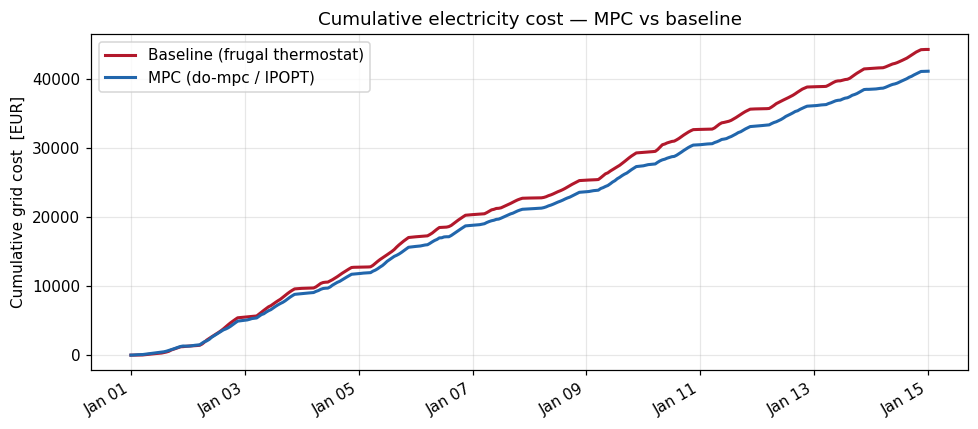

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(b.index, b.grid_cost_EUR.cumsum(), label='Baseline (frugal thermostat)', lw=2, color='#b2182b')
ax.plot(m.index, m.grid_cost_EUR.cumsum(), label='MPC (do-mpc / IPOPT)', lw=2, color='#2166ac')
ax.set_ylabel('Cumulative grid cost  [EUR]')
ax.set_title('Cumulative electricity cost — MPC vs baseline')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig1_cumulative_cost.png', bbox_inches='tight'); plt.show()

## 3. Grid exchange vs price
Negative grid power = export. The MPC imports in cheap hours and exports stored energy when prices peak.

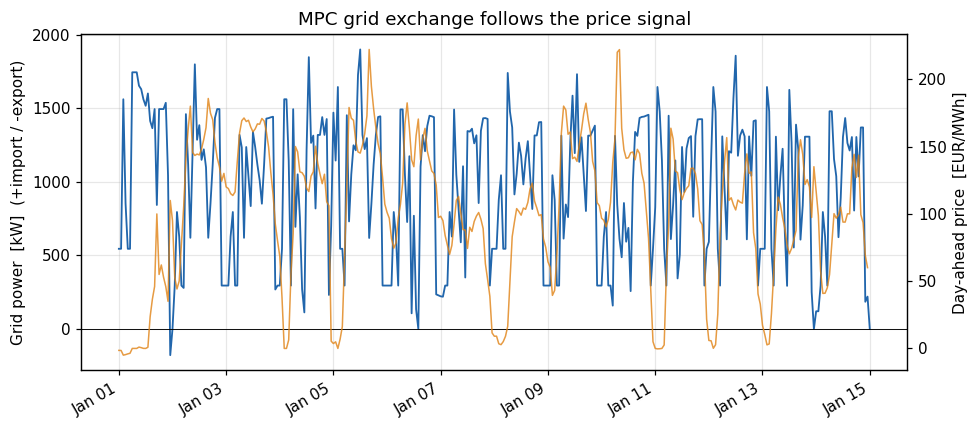

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m.index, m.u_P_grid, color='#2166ac', lw=1.2, label='MPC grid power [kW]')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Grid power  [kW]  (+import / -export)')
ax2 = ax.twinx()
ax2.plot(m.index, 1000*m.price_EUR_kWh, color='#e08214', lw=1.0, alpha=0.8)
ax2.set_ylabel('Day-ahead price  [EUR/MWh]'); ax2.grid(False)
ax.set_title('MPC grid exchange follows the price signal')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig2_grid_vs_price.png', bbox_inches='tight'); plt.show()

## 4. State-of-charge trajectories
Battery handles daily arbitrage; the hydrogen tank is a multi-day buffer; the thermal store shifts heating to cheap hours.

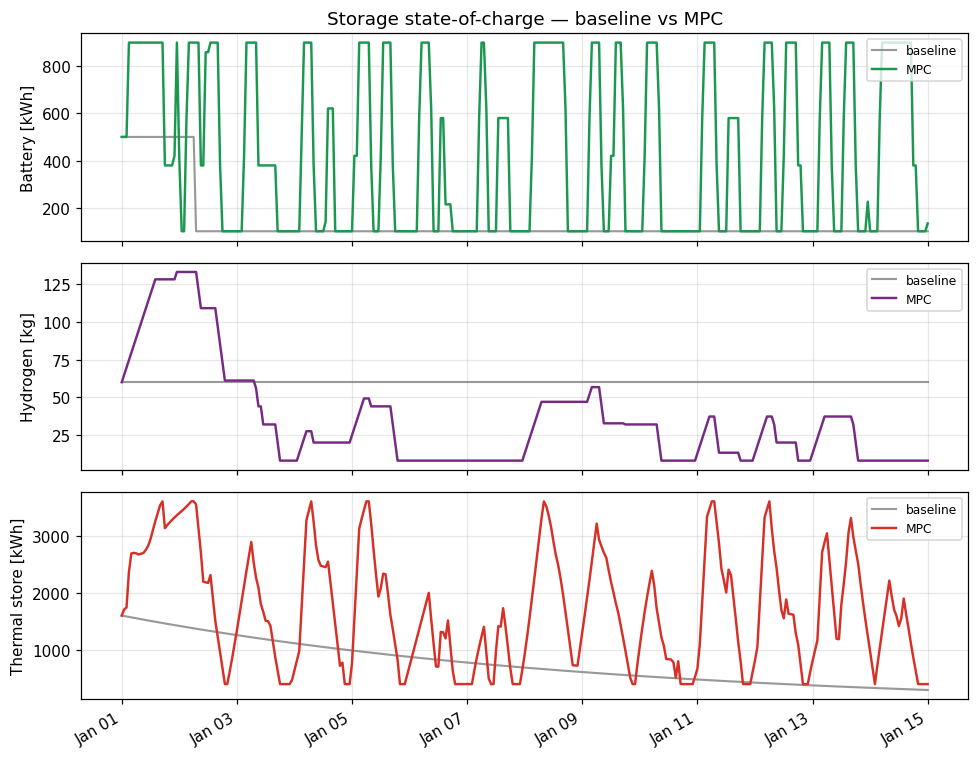

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, col, lab, cc in zip(axs, ['SOC_bat_kWh','SOC_h2_kg','SOC_tes_kWh'],
        ['Battery [kWh]','Hydrogen [kg]','Thermal store [kWh]'], ['#1a9850','#762a83','#d73027']):
    ax.plot(b.index, b[col], label='baseline', lw=1.4, color='grey', alpha=0.8)
    ax.plot(m.index, m[col], label='MPC', lw=1.6, color=cc)
    ax.set_ylabel(lab); ax.legend(loc='upper right', fontsize=8)
axs[0].set_title('Storage state-of-charge — baseline vs MPC')
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig3_soc_trajectories.png', bbox_inches='tight'); plt.show()

## 5. Greenhouse temperature
Both controllers keep the crop in the comfort band [16, 24] °C. The fair baseline holds the lower bound; the MPC additionally **pre-heats the thermal mass in cheap hours** (a demand-side flexibility) rather than just tracking it.

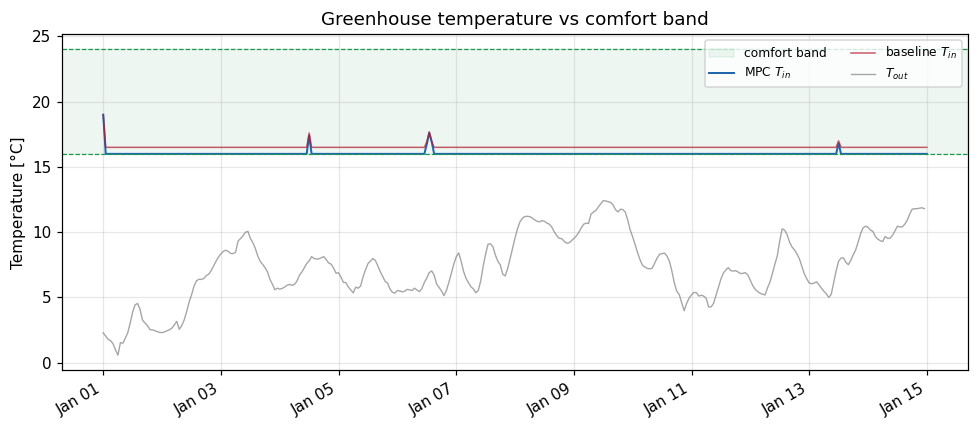

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhspan(16, 24, color='#1a9850', alpha=0.08, label='comfort band')
ax.plot(m.index, m.T_in_C, color='#2166ac', lw=1.3, label='MPC $T_{in}$')
ax.plot(b.index, b.T_in_C, color='#b2182b', lw=1.0, alpha=0.7, label='baseline $T_{in}$')
ax.plot(m.index, m.T_out_C, color='grey', lw=0.9, alpha=0.7, label='$T_{out}$')
ax.axhline(16, color='#1a9850', lw=0.8, ls='--'); ax.axhline(24, color='#1a9850', lw=0.8, ls='--')
ax.set_ylabel('Temperature [°C]'); ax.set_title('Greenhouse temperature vs comfort band')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig4_temperature.png', bbox_inches='tight'); plt.show()

## 6. Flexible heat: e-boiler load-shifting
The electric boiler (power-to-heat) is the CHP-replacement flexibility asset: the MPC runs it in cheap hours and stores the heat.

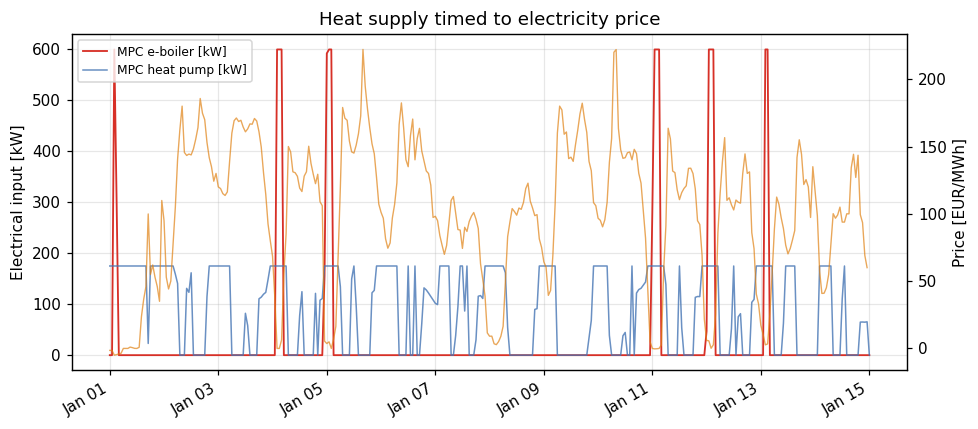

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m.index, m.u_P_eboiler, color='#d73027', lw=1.2, label='MPC e-boiler [kW]')
ax.plot(m.index, m.u_P_hp, color='#4575b4', lw=1.0, alpha=0.8, label='MPC heat pump [kW]')
ax.set_ylabel('Electrical input [kW]')
ax2 = ax.twinx(); ax2.plot(m.index, 1000*m.price_EUR_kWh, color='#e08214', lw=0.9, alpha=0.7)
ax2.set_ylabel('Price [EUR/MWh]'); ax2.grid(False)
ax.set_title('Heat supply timed to electricity price'); ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig5_heat_shifting.png', bbox_inches='tight'); plt.show()

## 7. Ablation — where the value comes from
Re-running the winter window with individual capabilities disabled isolates each contribution. Effective cost charges crop-comfort violations (so a controller cannot look cheap by letting the greenhouse drift out of band).

    variant  grid_eur  Tband_viol_Ch  effective_eur  grid_saving_pct  effective_saving_pct
 MPC (full)   41153.8            0.0        41153.8             7.12                  7.12
      no H2   41907.6            0.0        41907.6             5.42                  5.42
     no TES   46036.7            0.0        46036.7            -3.90                 -3.90
myopic (1h)   23093.7         2992.3        53016.9            47.88                -19.66


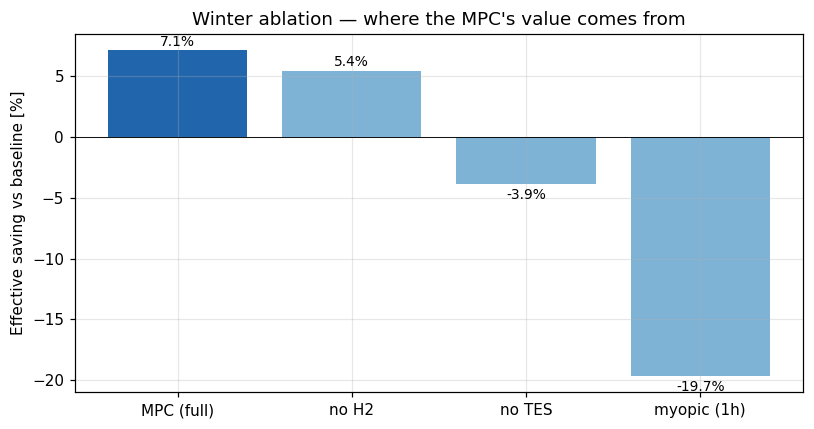

In [8]:
abl = pd.read_csv(RESULTS / 'scenarios' / 'ablations.csv')
print(abl.to_string(index=False))
fig, ax = plt.subplots(figsize=(7.5, 4))
colors = ['#2166ac'] + ['#7fb3d5']*(len(abl)-1)
bars = ax.bar(abl['variant'], abl['effective_saving_pct'], color=colors)
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Effective saving vs baseline [%]')
ax.set_title("Winter ablation — where the MPC's value comes from")
for bar, v in zip(bars, abl['effective_saving_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, v+(0.4 if v>=0 else -1.2), f'{v:.1f}%', ha='center', fontsize=9)
fig.tight_layout(); plt.show()

## Takeaways

- The MPC respects the electricity balance exactly and never charges/discharges a store simultaneously — the formulation is physically clean.
- It beats the fair baseline by **~7% in winter** (inventory-adjusted) through storage arbitrage, power-to-heat load-shifting, and thermal-mass pre-heating.
- The ablation shows the **thermal store is the decisive driver** (remove it and the MPC loses to the baseline), the **H₂ buffer adds a few points**, and **price foresight is essential to hold the comfort band** — the myopic controller looks cheap only because it lets the crop freeze.
- This is the economic-dispatch layer needed to replace the grid flexibility lost when Dutch greenhouse CHP units are phased out.